In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import ParameterSampler, ParameterGrid
# from dwsim_pilot_parametric_study_non_isoT import parametric_study

In [3]:
cols_F = ['F_Methane_out_dwsim', 'F_Ethane_out_dwsim',
       'F_Propane_out_dwsim', 'F_N-butane_out_dwsim', 'F_N-pentane_out_dwsim',
       'F_N-hexane_out_dwsim', 'F_N-heptane_out_dwsim', 'F_N-octane_out_dwsim',
       'F_N-nonane_out_dwsim', 'F_N-decane_out_dwsim',
       'F_N-undecane_out_dwsim', 'F_N-dodecane_out_dwsim',
       'F_N-tridecane_out_dwsim', 'F_N-tetradecane_out_dwsim',
       'F_N-pentadecane_out_dwsim', 'F_N-hexadecane_out_dwsim',
       'F_N-heptadecane_out_dwsim', 'F_N-octadecane_out_dwsim',
       'F_N-nonadecane_out_dwsim', 'F_N-heneicosane_out_dwsim',
       'F_N-docosane_out_dwsim', 'F_N-tetracosane_out_dwsim',
       'F_N-pentacosane_out_dwsim', 'F_N-hexacosane_out_dwsim',
       'F_N-heptacosane_out_dwsim', 'F_N-octacosane_out_dwsim',
       'F_N-nonacosane_out_dwsim', 'F_N-eicosane_out_dwsim',
       'F_Water_out_dwsim', 'F_Hydrogen_out_dwsim',
       'F_Carbon monoxide_out_dwsim', 'F_Ethylene_out_dwsim',
       'F_Propylene_out_dwsim', 'F_1-butene_out_dwsim', 'F_1-hexene_out_dwsim',
       'F_1-heptene_out_dwsim', 'F_1-octene_out_dwsim', 'F_1-nonene_out_dwsim',
       'F_1-decene_out_dwsim', 'F_1-undecene_out_dwsim',
       'F_1-dodecene_out_dwsim', 'F_1-tetradecene_out_dwsim',
       'F_1-hexadecene_out_dwsim', 'F_1-octadecene_out_dwsim',
       'F_N-tricosane_out_dwsim', 'F_Triacontane_out_dwsim',
       'F_Hentriacontane_out_dwsim', 'F_Dotriacontane_out_dwsim',
       'F_Tritriacontane_out_dwsim', 'F_Tetratriacontane_out_dwsim',
       'F_Pentatriacontane_out_dwsim', 'F_Hexatriacontane_out_dwsim',
       'F_1-pentene_out_dwsim', 'F_1-Tridecene_out_dwsim',
       'F_1-Pentadecene_out_dwsim', 'F_1-Heptadecene_out_dwsim',
       'F_Carbon dioxide_out_dwsim']

In [4]:
n_carbons = {'F_Methane_out_dwsim': 1, 'F_Ethane_out_dwsim': 2,
       'F_Propane_out_dwsim': 3, 'F_N-butane_out_dwsim': 4, 'F_N-pentane_out_dwsim': 5,
       'F_N-hexane_out_dwsim': 6, 'F_N-heptane_out_dwsim': 7, 'F_N-octane_out_dwsim': 8,
       'F_N-nonane_out_dwsim': 9, 'F_N-decane_out_dwsim': 10,
       'F_N-undecane_out_dwsim': 11, 'F_N-dodecane_out_dwsim': 12,
       'F_N-tridecane_out_dwsim': 13, 'F_N-tetradecane_out_dwsim': 14,
       'F_N-pentadecane_out_dwsim': 15, 'F_N-hexadecane_out_dwsim': 16,
       'F_N-heptadecane_out_dwsim': 17, 'F_N-octadecane_out_dwsim': 18,
       'F_N-nonadecane_out_dwsim': 19, 'F_N-heneicosane_out_dwsim': 21,
       'F_N-docosane_out_dwsim': 22, 'F_N-tetracosane_out_dwsim': 24,
       'F_N-pentacosane_out_dwsim': 25, 'F_N-hexacosane_out_dwsim': 26,
       'F_N-heptacosane_out_dwsim': 27, 'F_N-octacosane_out_dwsim': 28,
       'F_N-nonacosane_out_dwsim': 29, 'F_N-eicosane_out_dwsim': 20,
       'F_Ethylene_out_dwsim': 2,
       'F_Propylene_out_dwsim': 3, 'F_1-butene_out_dwsim': 4, 'F_1-hexene_out_dwsim': 6,
       'F_1-heptene_out_dwsim': 7, 'F_1-octene_out_dwsim': 8, 'F_1-nonene_out_dwsim': 9,
       'F_1-decene_out_dwsim': 10, 'F_1-undecene_out_dwsim': 11,
       'F_1-dodecene_out_dwsim': 12, 'F_1-tetradecene_out_dwsim': 13,
       'F_1-hexadecene_out_dwsim': 16, 'F_1-octadecene_out_dwsim': 18,
       'F_N-tricosane_out_dwsim': 23, 'F_Triacontane_out_dwsim': 30,
       'F_Hentriacontane_out_dwsim': 31, 'F_Dotriacontane_out_dwsim': 32,
       'F_Tritriacontane_out_dwsim': 33, 'F_Tetratriacontane_out_dwsim': 34,
       'F_Pentatriacontane_out_dwsim': 35, 'F_Hexatriacontane_out_dwsim': 36,
       'F_1-pentene_out_dwsim': 5, 'F_1-Tridecene_out_dwsim': 13,
       'F_1-Pentadecene_out_dwsim': 15, 'F_1-Heptadecene_out_dwsim': 17,
        }

In [5]:
double_bond = {'F_Methane_out_dwsim': False,
 'F_Ethane_out_dwsim': False,
 'F_Propane_out_dwsim': False,
 'F_N-butane_out_dwsim': False,
 'F_N-pentane_out_dwsim': False,
 'F_N-hexane_out_dwsim': False,
 'F_N-heptane_out_dwsim': False,
 'F_N-octane_out_dwsim': False,
 'F_N-nonane_out_dwsim': False,
 'F_N-decane_out_dwsim': False,
 'F_N-undecane_out_dwsim': False,
 'F_N-dodecane_out_dwsim': False,
 'F_N-tridecane_out_dwsim': False,
 'F_N-tetradecane_out_dwsim': False,
 'F_N-pentadecane_out_dwsim': False,
 'F_N-hexadecane_out_dwsim': False,
 'F_N-heptadecane_out_dwsim': False,
 'F_N-octadecane_out_dwsim': False,
 'F_N-nonadecane_out_dwsim': False,
 'F_N-heneicosane_out_dwsim': False,
 'F_N-docosane_out_dwsim': False,
 'F_N-tetracosane_out_dwsim': False,
 'F_N-pentacosane_out_dwsim': False,
 'F_N-hexacosane_out_dwsim': False,
 'F_N-heptacosane_out_dwsim': False,
 'F_N-octacosane_out_dwsim': False,
 'F_N-nonacosane_out_dwsim': False,
 'F_N-eicosane_out_dwsim': False,
 'F_Ethylene_out_dwsim': True,
 'F_Propylene_out_dwsim': True,
 'F_1-butene_out_dwsim': True,
 'F_1-hexene_out_dwsim': True,
 'F_1-heptene_out_dwsim': True,
 'F_1-octene_out_dwsim': True,
 'F_1-nonene_out_dwsim': True,
 'F_1-decene_out_dwsim': True,
 'F_1-undecene_out_dwsim': True,
 'F_1-dodecene_out_dwsim': True,
 'F_1-tetradecene_out_dwsim': True,
 'F_1-hexadecene_out_dwsim': True,
 'F_1-octadecene_out_dwsim': True,
 'F_N-tricosane_out_dwsim': False,
 'F_Triacontane_out_dwsim': False,
 'F_Hentriacontane_out_dwsim': False,
 'F_Dotriacontane_out_dwsim': False,
 'F_Tritriacontane_out_dwsim': False,
 'F_Tetratriacontane_out_dwsim': False,
 'F_Pentatriacontane_out_dwsim': False,
 'F_Hexatriacontane_out_dwsim': False,
 'F_1-pentene_out_dwsim': True,
 'F_1-Tridecene_out_dwsim': True,
 'F_1-Pentadecene_out_dwsim': True,
 'F_1-Heptadecene_out_dwsim': True}

In [6]:
MM = {}
for key in n_carbons.keys():
    if double_bond[key]:
        MM[key] = 12 * n_carbons[key] + 2 * n_carbons[key]
    else:
        MM[key] = 12 * n_carbons[key] + 2 * n_carbons[key] + 2
MM['F_Carbon dioxide_out_dwsim'] = 44
MM['F_Water_out_dwsim'] = 18
MM['F_Hydrogen_out_dwsim'] = 2
MM['F_Carbon monoxide_out_dwsim'] = 28

In [7]:
cols_Fout_C1_C4 = [key for key, value in n_carbons.items() if value in range(1,5)]
cols_Fout_C5_C8 = [key for key, value in n_carbons.items() if value in range(5,9)]
cols_Fout_C9_C15 = [key for key, value in n_carbons.items() if value in range(9,16)]
cols_Fout_C16p = [key for key, value in n_carbons.items() if value in range(16,37)]
cols_Fout_C5p = [key for key, value in n_carbons.items() if value in range(5,37)]

In [8]:
MM_C1_C4 = {comp: MM[comp] for comp in cols_Fout_C1_C4}
MM_C5_C8 = {comp: MM[comp] for comp in cols_Fout_C5_C8}
MM_C9_C15 = {comp: MM[comp] for comp in cols_Fout_C9_C15}
MM_C16p = {comp: MM[comp] for comp in cols_Fout_C16p}
MM_C5p = {comp: MM[comp] for comp in cols_Fout_C5p}

In [9]:
def complete_data(data):
    data['H2_CO'] = data.F_H2_in / data.F_CO_in
    data['T (ºC)'] = data.T_out_K - 273.15
    data['P (bar)'] = data.P_Pa / 1e5
    data[r'$X_\mathrm{CO}$'] = (
        (data.F_CO_in - data['F_Carbon monoxide_out_dwsim']) / data.F_CO_in
    )
    data[r'$X_\mathrm{H_2}$'] = (
        (data.F_H2_in - data['F_Hydrogen_out_dwsim']) / data.F_H2_in
    )
    data[r'$\mathrm{v_{CO,in}}$ (L/min)'] =  1000 * 60 * data.F_CO_in * 8.314 * 273 / 1e5
    data[r'$\mathrm{v_{H_2,in}}$ (L/min)'] = 1000 * 60 * data.F_H2_in * 8.314 * 273 / 1e5
    
    Fout_C1_C4 = data[cols_Fout_C1_C4]
    Fout_C5_C8 = data[cols_Fout_C5_C8]
    Fout_C9_C15 = data[cols_Fout_C9_C15]
    Fout_C16p = data[cols_Fout_C16p]
    Fout_C5p = data[cols_Fout_C5p]
    
    mout_C1_C4 = Fout_C1_C4.mul(MM_C1_C4, axis = 'columns')
    mout_C5_C8 = Fout_C5_C8.mul(MM_C5_C8, axis = 'columns')
    mout_C9_C15 = Fout_C9_C15.mul(MM_C9_C15, axis = 'columns')
    mout_C16p = Fout_C16p.mul(MM_C16p, axis = 'columns')
    mout_C5p = Fout_C5p.mul(MM_C5p, axis = 'columns')
    
    data[r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)'] = mout_C1_C4.sum(axis = 'columns') * 86400 / 1000 # $\mathrm{kg~d^{-1}}$
    data[r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)'] = mout_C5_C8.sum(axis = 'columns') * 86400 / 1000 # $\mathrm{kg~d^{-1}}$
    data[r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)'] = mout_C9_C15.sum(axis = 'columns') * 86400 / 1000 # $\mathrm{kg~d^{-1}}$
    data[r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)'] = mout_C16p.sum(axis = 'columns') * 86400 / 1000 # $\mathrm{kg~d^{-1}}$
    data[r'$\dot{m}_\mathrm{{C5+}}$ ($\mathrm{kg~d^{-1}}$)'] = mout_C5p.sum(axis = 'columns') * 86400 / 1000 # $\mathrm{kg~d^{-1}}$
    data[r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)'] = data['F_Carbon dioxide_out_dwsim'] * 44 * 86400 / 1000
    data[r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)'] = data['F_Water_out_dwsim'] * 18 * 86400 / 1000
    
    data['C1_C4_sel'] = data[r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data['C5_C8_sel'] = data[r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data['C9_C15_sel'] = data[r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data['C16p_sel'] = data[r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data['CO2_sel'] = data[r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data['H2O_sel'] = data[r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data[r'$\dot{m}_\mathrm{HCs}$ ($\mathrm{kg~d^{-1}}$)'] = (
    data[[r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)']].sum(axis = 'columns')
)
    return data

In [10]:
# Paths
dwsim_path = r"C:\Users\rafae\AppData\Local\DWSIM\\"
sim_path = r"C:\Users\rafae\Documents\Rafael Duarte\SAF_kinetics_paper_code_with_WGS\SAF_kinetics_paper_code_with_WGS\dwsim_pilot_model_parametric_non_isoT.dwxmz"

In [11]:
m0 = 500 # kg / d
m0 = m0 * 1000 / ( 24 * 60 * 60 ) # g / s

H2_CO_in = 2
x_H2_in = (H2_CO_in / ( 1 + H2_CO_in ))
x_CO_in = 1 - x_H2_in

MM = 2 * x_H2_in + 28 * x_CO_in

F0 = m0 / MM

F_H2_in = F0 * x_H2_in
F_CO_in = F0 * x_CO_in

In [12]:
2*F_H2_in * 24*60*60/1000 + 28*F_CO_in * 24*60*60/1000

499.99999999999994

In [13]:
V_m3 = 0.2
param_grid = {'T_out_K'        : np.arange(210 + 273.15, 281 + 273.15, 1), 
              'P_Pa'       : [20e5],
              'F_H2_in'    : [F_H2_in],
              'F_CO_in'    : [F_CO_in],
              'phi_220C'   : [0.001, 2, 4, 10],
              'V_m3'       : [V_m3],
             }

parametric_data = pd.DataFrame(ParameterGrid(param_grid))

parametric_data = parametric_study(parametric_data, num_workers:=16, dwsim_path, sim_path)

parametric_data = complete_data(parametric_data)
parametric_data.to_pickle('parametric_data_dwsim_pilot_non_isoT.pkl')
parametric_data.to_excel('parametric_data_dwsim_pilot_non_isoT.ods')

In [14]:
parametric_data = pd.read_pickle('parametric_data_dwsim_pilot_non_isoT.pkl')

In [15]:
fig_path = '/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'

In [16]:
De = 48.3 / 1000 # m
L = 4 * V_m3 / (np.pi * De ** 2) # m

A = np.pi * De * L # m²

deltaT1 = 210 - 190
deltaT2 = parametric_data.T_out_K - ( 190 + 273.15 )
parametric_data['LMTD (K)'] = ( deltaT1 - deltaT2 ) / np.log( deltaT1 / deltaT2 )
parametric_data['U (W/m²/K)'] = - 1000 * parametric_data['Reactor Energy Flow (kW)'] / ( A * parametric_data['LMTD (K)'] )

parametric_data['X_syngas'] = parametric_data[[r'$X_\mathrm{CO}$', 
                                               r'$X_\mathrm{H_2}$']].mean(axis = 'columns')

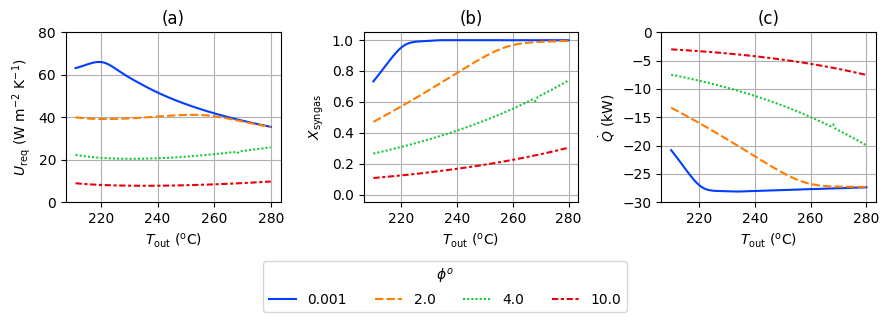

In [33]:
fig, axs = plt.subplots(1,3, figsize=(9,2.7))

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = 'U (W/m²/K)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = axs[0]
            )
axs[0].grid('both')
axs[0].set_ylim(0, 80)
axs[0].set_title('(a)')
axs[0].legend(title = r'$\phi^o$').remove()
axs[0].set_xlabel(r'$T_\mathrm{out}$ ($\mathrm{^oC}$)')
axs[0].set_ylabel(r'$U_\mathrm{req}~\mathrm{(W~m^{-2}~K^{-1})}$')

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = 'X_syngas', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = axs[1]
            )
axs[1].grid('both')
axs[1].set_ylim(-0.05, 1.05)
axs[1].set_title('(b)')
axs[1].legend(title = r'$\phi^o$', bbox_to_anchor=(1.02, 1)).remove()
axs[1].set_xlabel(r'$T_\mathrm{out}$ ($\mathrm{^oC}$)')
axs[1].set_ylabel(r'$X_\mathrm{syngas}$')

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = 'Reactor Energy Flow (kW)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = axs[2]
            )
axs[2].grid('both')
axs[2].set_title('(c)')
axs[2].legend(title = r'$\phi^o$', bbox_to_anchor=(0, 1), ncols = 4).remove()
axs[2].set_xlabel(r'$T_\mathrm{out}$ ($\mathrm{^oC}$)')
axs[2].set_ylabel(r'$\dot{Q}$ (kW)')
axs[2].set_ylim(-30, 0)

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.2), # Adjust 0.92 to move it up or down
           ncol=4, 
           frameon=True,
           title = r'$\phi^o$',
          )

plt.tight_layout()

fig_name = 'U_req_dwsim.pdf'
plt.savefig(fig_path+fig_name, bbox_inches = 'tight')
plt.show()

In [27]:
parametric_data.loc[(parametric_data['U (W/m²/K)'] == parametric_data['U (W/m²/K)'].max()), 'T (ºC)']

36    219.0
Name: T (ºC), dtype: float64

In [28]:
parametric_data.loc[(parametric_data['U (W/m²/K)'] == parametric_data['U (W/m²/K)'].max())]

,F_CO_in,F_H2_in,P_Pa,T_out_K,V_m3,phi_220C,Reactor Energy Flow (kW),F_Methane_out_dwsim,F_Ethane_out_dwsim,F_Propane_out_dwsim,...,C1_C4_sel,C5_C8_sel,C9_C15_sel,C16p_sel,CO2_sel,H2O_sel,$\dot{m}_\mathrm{HCs}$ ($\mathrm{kg~d^{-1}}$),LMTD (K),U (W/m²/K),X_syngas
36,0.180845,0.36169,2000000.0,492.15,0.2,0.001,-26.494687,0.005878,0.000194,0.00152,...,0.048732,0.075469,0.150801,0.232346,0.017108,1.20731,201.792453,24.221966,66.03992,0.934649


In [29]:
3*66

198

In [25]:
parametric_data.loc[(parametric_data.phi_220C == 0.001) & (parametric_data['T (ºC)'] == 250)]

,F_CO_in,F_H2_in,P_Pa,T_out_K,V_m3,phi_220C,Reactor Energy Flow (kW),F_Methane_out_dwsim,F_Ethane_out_dwsim,F_Propane_out_dwsim,...,C1_C4_sel,C5_C8_sel,C9_C15_sel,C16p_sel,CO2_sel,H2O_sel,$\dot{m}_\mathrm{HCs}$ ($\mathrm{kg~d^{-1}}$),LMTD (K),U (W/m²/K),X_syngas
160,0.180845,0.36169,2000000.0,523.15,0.2,0.001,-27.844573,0.007606,0.000289,0.001945,...,0.058338,0.084832,0.15634,0.190463,0.050586,1.097915,214.137647,36.409569,46.17237,0.99882
